# Comparative Study of Machine Learning and Deep Learning for Hate Speech Classification

**Course:** Machine Learning — Semester I, Academic Year 2025–2026  
**Department:** Computer Science, Ho Chi Minh City University of Technology, VNU-HCM  
**Supervisor:** TS. Lê Thành Sách  

---

## Notebook Overview

This notebook implements the full **Assignment: Machine Learning with Text Data** pipeline:

| Step | Description |
|------|-------------|
| 1 | **EDA** — class distribution, tweet length, word frequency, word clouds |
| 2 | **Preprocessing** — tweet-specific cleaning, emoji conversion, lemmatization |
| 3 | **Feature Extraction** — 5 methods (3 traditional + 2 deep learning) |
| 4 | **Save features** — sparse `.npz` for BoW/TF-IDF, dense `.npy` for GloVe/DistilBERT |

**Feature methods:**
- Traditional: Bag-of-Words · TF-IDF (word, unigram+bigram) · Char n-gram TF-IDF
- Modern: GloVe Twitter 200d (averaged) · DistilBERT CLS token (768-dim)

**Dataset:** `twitter_toxic_tweets.csv` — 31,962 tweets, binary label (0=non-toxic, 1=toxic)

## 0. Setup

In [4]:
# ── Install required libraries (uncomment if running in a fresh environment) ──
# !pip install -q pandas numpy scikit-learn matplotlib seaborn wordcloud emoji tqdm
# !pip install -q transformers torch
# !python -m spacy download en_core_web_sm  # only needed if using spaCy

In [5]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ── Path configuration ────────────────────────────────────────────────────────
import pathlib

# Detect environment: Colab vs local
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

# Root of the project (parent of notebooks/)
NOTEBOOK_DIR = pathlib.Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
print(f"Project root: {PROJECT_ROOT}")

# Add modules/ to Python path so we can import our helpers
MODULES_DIR = PROJECT_ROOT / 'modules'
if str(MODULES_DIR) not in sys.path:
    sys.path.insert(0, str(MODULES_DIR))

DATA_DIR    = PROJECT_ROOT / 'datas'
FEATURES_DIR = PROJECT_ROOT / 'features'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

Running locally
Project root: C:\Users\PC\Downloads\MachineLearning\ML-Course-Project


In [6]:
# ── If running in Colab: download the dataset ─────────────────────────────────
# The dataset is hosted publicly on Kaggle (https://www.kaggle.com/datasets/...)
# and mirrored via the link below for direct download.
#
# HOW TO USE:
#   1. Upload twitter_toxic_tweets.csv to a public GitHub release or Kaggle dataset.
#   2. Replace DATA_URL below with the direct download link.
#   3. The cell will auto-download on Colab; locally it reads from datas/.

DATA_URL = "https://YOUR_PUBLIC_LINK/twitter_toxic_tweets.csv"  # <- replace

if IN_COLAB:
    import urllib.request
    DATA_DIR = pathlib.Path('/content/datas')
    DATA_DIR.mkdir(exist_ok=True)
    csv_path = DATA_DIR / 'twitter_toxic_tweets.csv'
    if not csv_path.exists():
        print("Downloading dataset...")
        urllib.request.urlretrieve(DATA_URL, csv_path)
        print("Done.")
    FEATURES_DIR = pathlib.Path('/content/features')
    FEATURES_DIR.mkdir(exist_ok=True)
else:
    csv_path = DATA_DIR / 'twitter_toxic_tweets.csv'

In [7]:
# ── Core imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from preprocessing import preprocess_dataframe, show_examples
import feature_extraction as fe
import utils

utils.set_style()

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## 1. Data Loading

In [8]:
df = pd.read_csv(csv_path)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(5)

Shape: (31962, 3)
Columns: ['id', 'label', 'tweet']


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [9]:
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Data types:
id       int64
label    int64
tweet      str
dtype: object

Missing values:
id       0
label    0
tweet    0
dtype: int64


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Class Distribution

In [10]:
label_counts = df['label'].value_counts().sort_index()
label_names  = {0: 'Non-toxic', 1: 'Toxic'}

print("Class distribution:")
for lbl, cnt in label_counts.items():
    print(f"  {label_names[lbl]:>10} (label={lbl}): {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")
print(f"\nImbalance ratio: {label_counts[0]/label_counts[1]:.1f}:1  (non-toxic:toxic)")
print("⚠  Severe imbalance — models trained naively will be biased toward the majority class.")

Class distribution:
   Non-toxic (label=0): 29,720  (93.0%)
       Toxic (label=1):  2,242  (7.0%)

Imbalance ratio: 13.3:1  (non-toxic:toxic)
⚠  Severe imbalance — models trained naively will be biased toward the majority class.


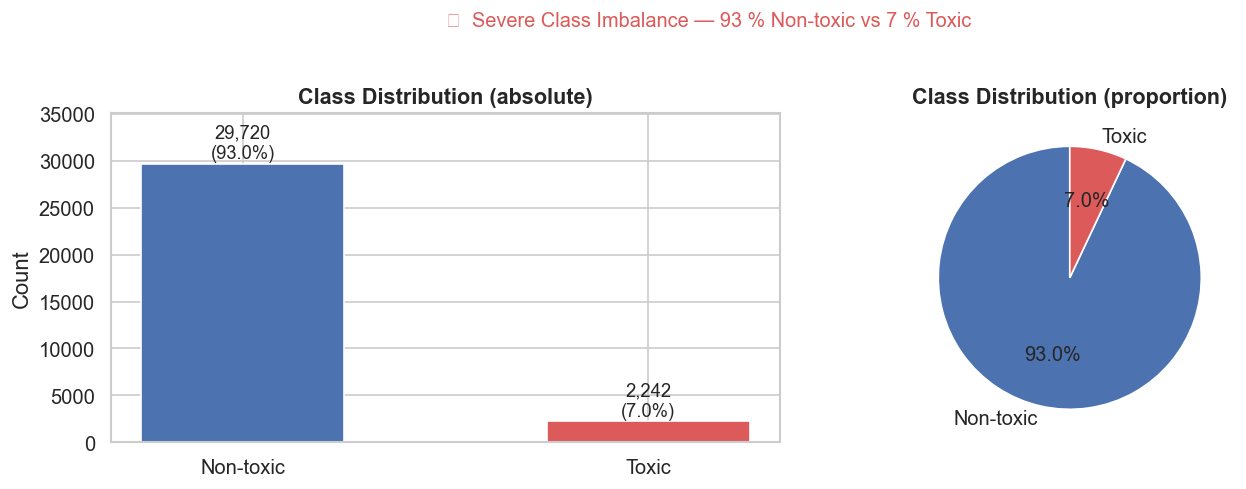

In [11]:
utils.plot_class_distribution(df)

### 2.2 Tweet Length Distribution

In [12]:
stats = utils.eda_summary(df, text_col='tweet', label_col='label')
print("Tweet length statistics (raw tweets):")
stats

Tweet length statistics (raw tweets):


char_len                       word_count                    
              mean median   std min  max       mean median  std min max
Non-toxic     84.3   88.0  29.6  11  274       13.1   13.0  5.5   3  34
Toxic         90.2   96.0  27.4  12  152       14.1   14.0  5.0   3  30

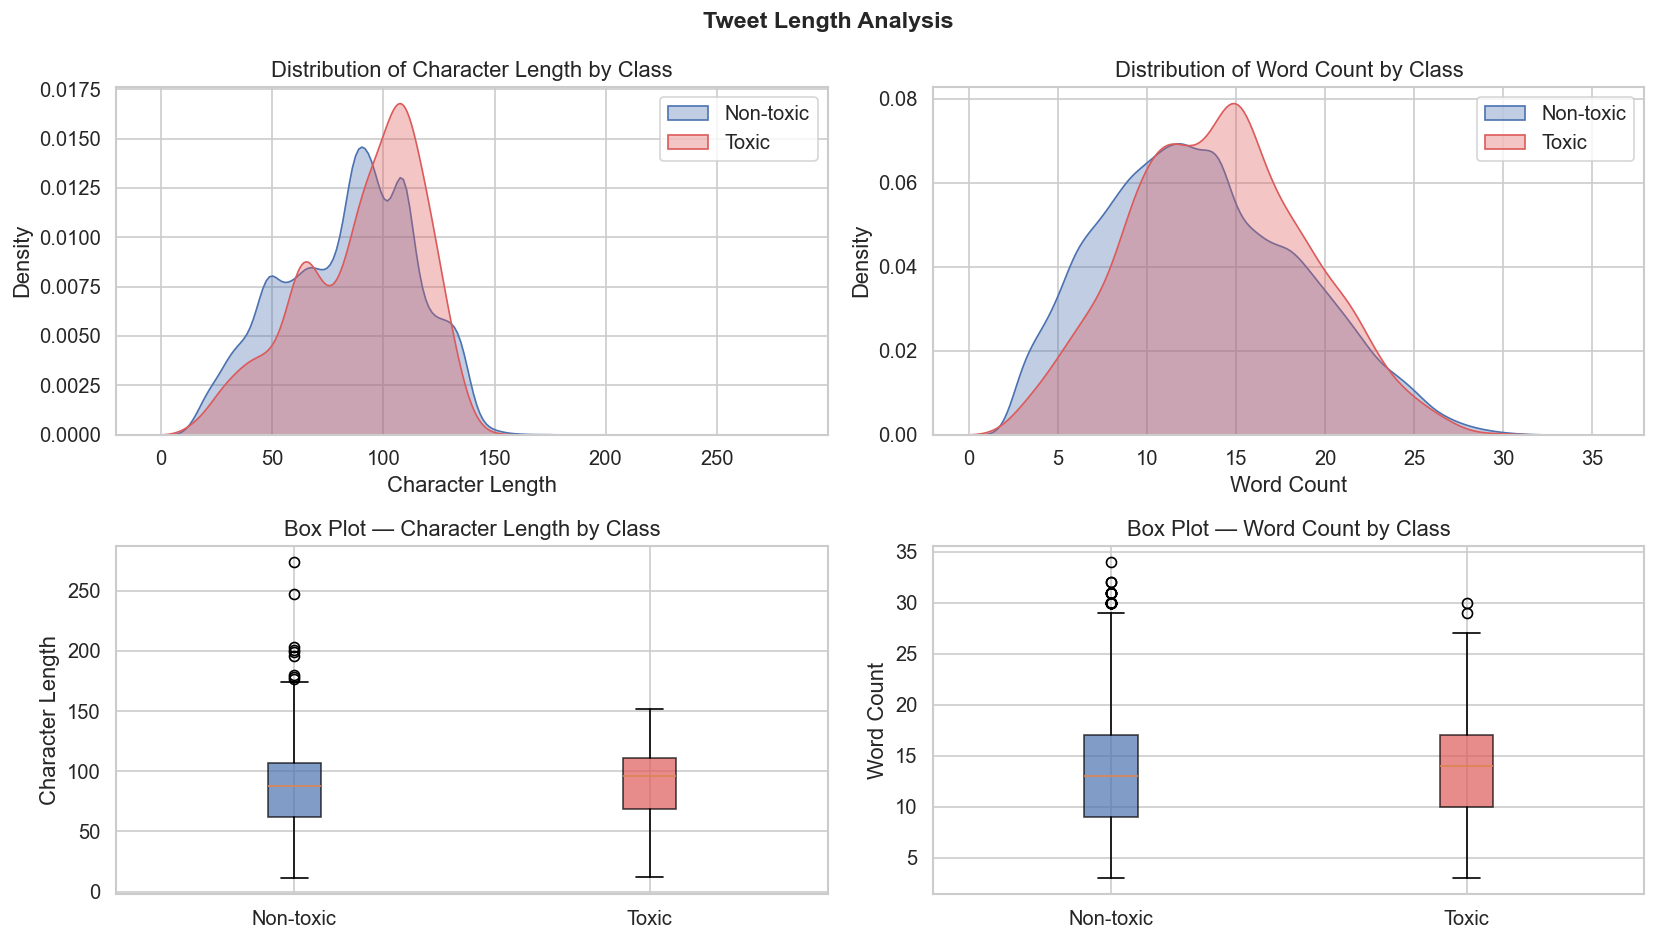

In [13]:
utils.plot_tweet_length_distribution(df)

### 2.3 Preprocessing (required before word-frequency EDA)

In [14]:
# NOTE: full preprocessing is in Section 3.
# We run it here first so EDA plots show *cleaned* word frequencies.
print("Applying preprocessing pipeline (this may take ~1-2 min)...")
df = preprocess_dataframe(df, text_col='tweet')
print("Done.")
df[['tweet', 'tweet_clean', 'tweet_bert']].head(3)

Applying preprocessing pipeline (this may take ~1-2 min)...


Cleaning (BERT): 100%|██████████| 31962/31962 [00:02<00:00, 10724.09it/s]

Done.


,tweet,tweet_clean,tweet_bert
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...,when a father is dysfunctional and is so selfi...
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit use cause offer wheelchair ...,thanks for lyft credit i can t use cause they ...
2,bihday your majesty,bihday majesty,bihday your majesty


### 2.4 Word Frequency Analysis

In [15]:
vocab = utils.vocabulary_stats(df, text_col='tweet_clean')
print("Vocabulary statistics (after preprocessing):")
for k, v in vocab.items():
    print(f"  {k}: {v:,}")

Vocabulary statistics (after preprocessing):
  total_tokens: 243,817
  unique_tokens: 35,364
  avg_tokens_per_tweet: 7.6


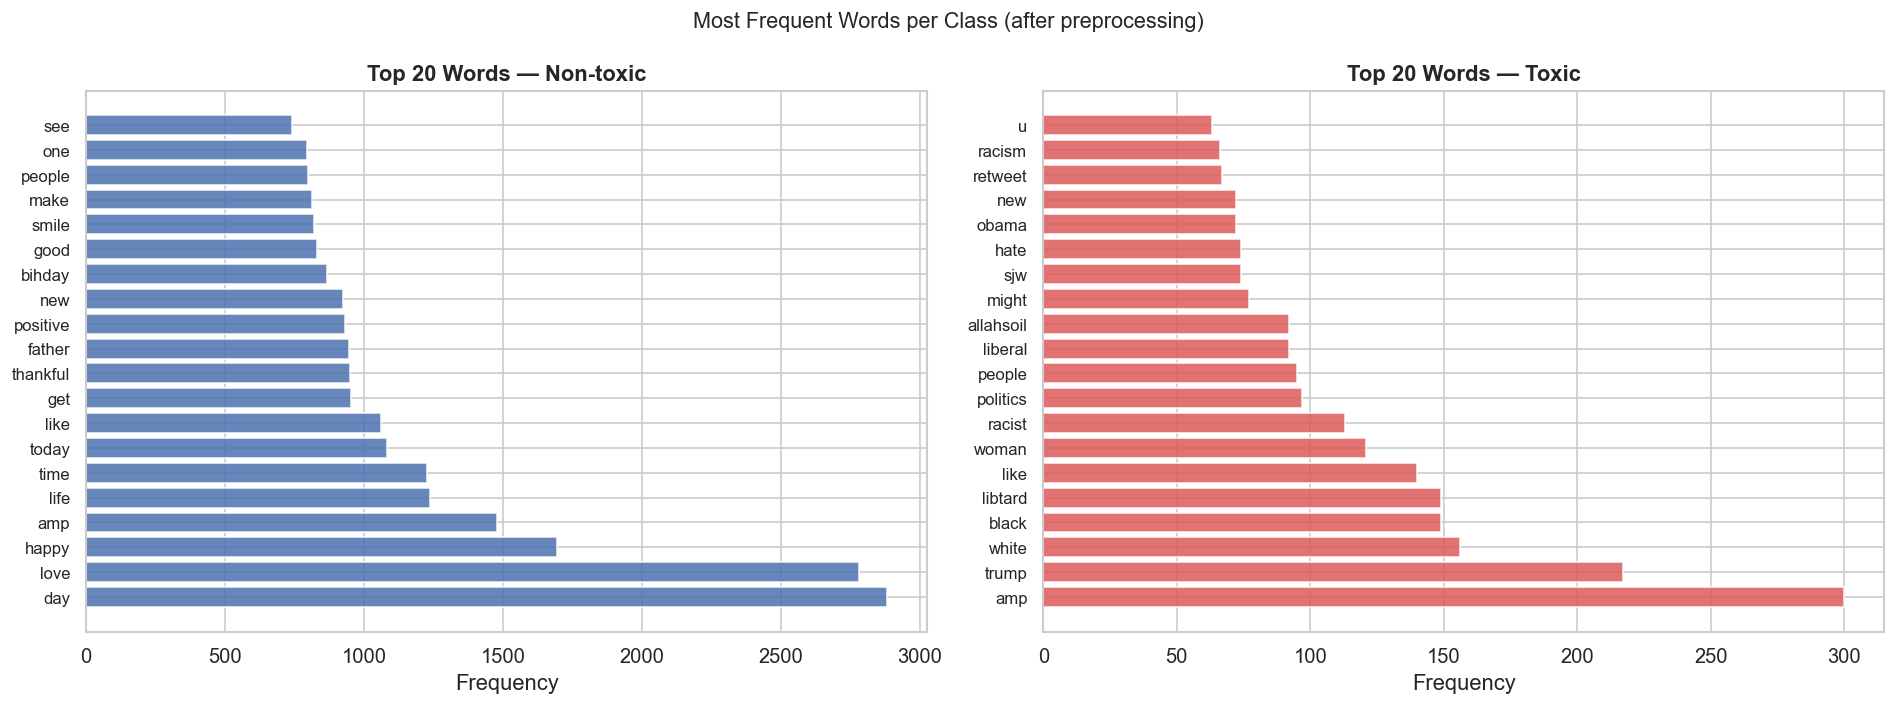

In [16]:
utils.plot_top_words(df, text_col='tweet_clean', top_n=20)

### 2.5 Word Clouds

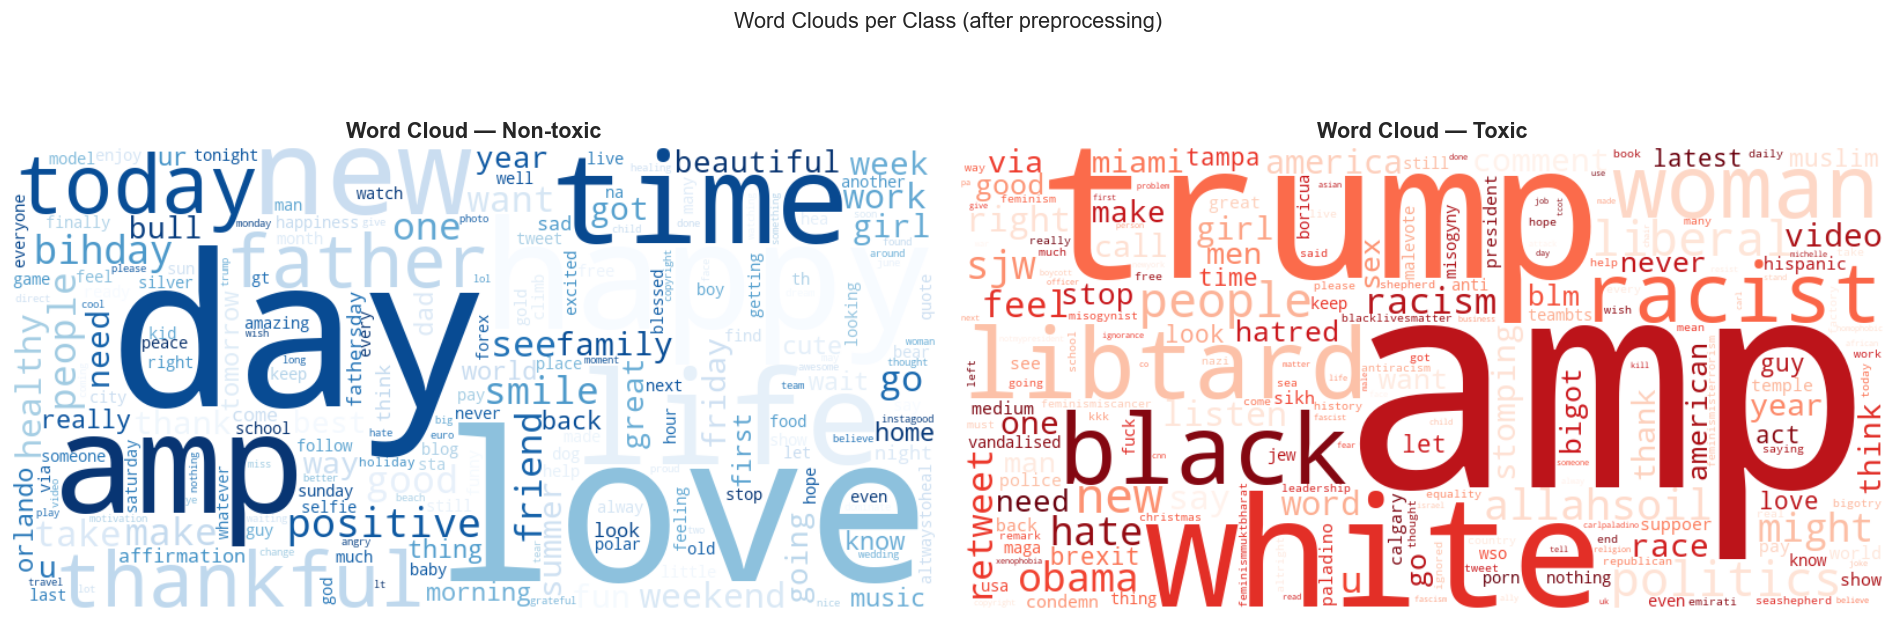

In [17]:
utils.plot_wordclouds(df, text_col='tweet_clean')

---
## 3. Preprocessing Pipeline

The cleaning steps applied (implemented in `modules/preprocessing.py`):

| Step | Description |
|------|-------------|
| 1 | Emoji → text description (e.g. 😡 → `angry_face`) |
| 2 | Lowercase |
| 3 | Remove URLs |
| 4 | Remove @mentions |
| 5 | Hashtags: strip `#`, keep word |
| 6 | Remove numbers |
| 7 | Remove punctuation / special chars |
| 8 | Tokenize |
| 9 | Remove English stopwords (NLTK) |
| 10 | Lemmatize (NLTK WordNetLemmatizer) |

Two variants:
- **`tweet_clean`**: full pipeline — used for BoW, TF-IDF, GloVe
- **`tweet_bert`**: steps 1–7 only (no stopword removal / lemmatization) — used for DistilBERT, which has its own tokenizer

In [18]:
# Show before/after examples
show_examples(df, n=6)

,tweet,tweet_clean,tweet_bert,label
0,@user âmy mom says my smile is captivatingâ...,mom say smile captivating say happy sunday pug...,my mom says my smile is captivating i says hap...,0
1,"in 3 days i will be meeting my sis-n-law, coun...",day meeting si law couney bower first le vel l...,in days i will be meeting my sis n law couney ...,0
2,hating the conservative homophobes using this ...,hating conservative homophobe using tragedy wa...,hating the conservative homophobes using this ...,0
3,awee if this doesn't #scream #friday #acewe...,awee scream friday acewellstucker cynthiabaile...,awee if this doesn t scream friday acewellstuc...,0
4,fathersday #fatherÃ¢ÂÂs #day #god! #ÃÂ« #...,fathersday father day god tony smith buy thing...,fathersday father s day god tony a smith buy t...,0
5,grooving fuuuunn nightâ¨â¨â¨ #bangkok #las...,grooving fuuuunn night bangkok lastnight copyr...,grooving fuuuunn night bangkok lastnight copyr...,0


In [19]:
# Check for any empty strings after cleaning
empty_clean = (df['tweet_clean'].str.strip() == '').sum()
empty_bert  = (df['tweet_bert'].str.strip() == '').sum()
print(f"Empty tweet_clean after cleaning : {empty_clean}")
print(f"Empty tweet_bert  after cleaning : {empty_bert}")

# Replace empty strings with a placeholder to avoid vectorizer errors
df['tweet_clean'] = df['tweet_clean'].replace('', 'unknown')
df['tweet_bert']  = df['tweet_bert'].replace('', 'unknown')

Empty tweet_clean after cleaning : 38
Empty tweet_bert  after cleaning : 2


---
## 4. Train / Test Split

Split **before** feature extraction so vectorizers are fit on training data only (prevents data leakage).

- Split: **80% train / 20% test**  
- Stratified on `label` to preserve the 93:7 class ratio in both splits

In [20]:
X_clean = df['tweet_clean'].values
X_bert  = df['tweet_bert'].values
y       = df['label'].values

(
    X_clean_train, X_clean_test,
    X_bert_train,  X_bert_test,
    y_train,       y_test
) = train_test_split(
    X_clean, X_bert, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train size : {len(y_train):,}  (toxic: {y_train.sum():,} = {y_train.mean()*100:.1f}%)")
print(f"Test  size : {len(y_test):,}   (toxic: {y_test.sum():,}  = {y_test.mean()*100:.1f}%)")

# Save labels
np.save(FEATURES_DIR / 'y_train.npy', y_train)
np.save(FEATURES_DIR / 'y_test.npy',  y_test)
print(f"\nLabels saved to {FEATURES_DIR}")

Train size : 25,569  (toxic: 1,794 = 7.0%)
Test  size : 6,393   (toxic: 448  = 7.0%)

Labels saved to C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\features


---
## 5. Feature Extraction

All extractors are implemented in `modules/feature_extraction.py`.  
Each is fit on **training data only** and applied to test data to avoid leakage.

### 5.1 Bag-of-Words (BoW)

**CountVectorizer** — unigram, top 10,000 vocabulary terms.  
Represents each tweet as a sparse vector of raw token counts.  
Simple but effective baseline; ignores word order and importance weighting.

In [21]:
print("Extracting Bag-of-Words features...")
bow_train, bow_test, bow_vec = fe.extract_bow(
    X_clean_train, X_clean_test, max_features=10_000
)

fe.save_sparse(bow_train, str(FEATURES_DIR / 'bow_train.npz'))
fe.save_sparse(bow_test,  str(FEATURES_DIR / 'bow_test.npz'))

print(f"Vocabulary size: {len(bow_vec.vocabulary_):,}")
print(f"Sample top-20 tokens: {list(bow_vec.vocabulary_.keys())[:20]}")

Extracting Bag-of-Words features...
  BoW  → train (25569, 10000), test (6393, 10000)
  Saved sparse → C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\features\bow_train.npz  (0.4 MB)
  Saved sparse → C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\features\bow_test.npz  (0.1 MB)
Vocabulary size: 10,000
Sample top-20 tokens: ['first', 'order', 'something', 'black', 'amp', 'sexy', 'collection', 'cantwait', 'although', 'told', 'andrew', 'jackson', 'also', 'video', 'hateful', 'liberal', 'america', 'enough', 'crap', 'monaco']


### 5.2 TF-IDF (Word, Unigram + Bigram)

**TfidfVectorizer** — word-level, n-gram range (1,2), top 15,000 features, `sublinear_tf=True`.  
Weights tokens by their *importance* (high in document, rare across corpus).  
Bigrams capture local context: "hate speech", "not offensive", etc.

In [22]:
print("Extracting TF-IDF (word) features...")
tfidf_train, tfidf_test, tfidf_vec = fe.extract_tfidf(
    X_clean_train, X_clean_test,
    max_features=15_000,
    ngram_range=(1, 2)
)

fe.save_sparse(tfidf_train, str(FEATURES_DIR / 'tfidf_train.npz'))
fe.save_sparse(tfidf_test,  str(FEATURES_DIR / 'tfidf_test.npz'))

# Show top features by mean TF-IDF score on toxic tweets
import numpy as np
toxic_mask = y_train == 1
mean_tfidf_toxic = np.asarray(tfidf_train[toxic_mask].mean(axis=0)).flatten()
top_idx = mean_tfidf_toxic.argsort()[::-1][:15]
feature_names = tfidf_vec.get_feature_names_out()
print("\nTop 15 TF-IDF terms in TOXIC tweets:")
print([feature_names[i] for i in top_idx])

Extracting TF-IDF (word) features...
  TF-IDF (word (1, 2)) → train (25569, 15000), test (6393, 15000)
  Saved sparse → C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\features\tfidf_train.npz  (1.8 MB)
  Saved sparse → C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\features\tfidf_test.npz  (0.4 MB)

Top 15 TF-IDF terms in TOXIC tweets:
['amp', 'trump', 'white', 'libtard', 'black', 'woman', 'racist', 'allahsoil', 'politics', 'liberal', 'like', 'sjw', 'sjw liberal', 'liberal politics', 'libtard libtard']


### 5.3 Character N-gram TF-IDF

**TfidfVectorizer** — `analyzer='char_wb'`, n-gram range (3,5), top 10,000 features.  
Character-level: captures misspellings, abbreviations, slang (e.g. `"h8"`, `"kys"`).  
Particularly valuable for hate speech where attackers deliberately obfuscate words.

In [23]:
print("Extracting Character n-gram TF-IDF features...")
char_train, char_test, char_vec = fe.extract_char_tfidf(
    X_clean_train, X_clean_test,
    max_features=10_000,
    ngram_range=(3, 5)
)

fe.save_sparse(char_train, str(FEATURES_DIR / 'char_tfidf_train.npz'))
fe.save_sparse(char_test,  str(FEATURES_DIR / 'char_tfidf_test.npz'))

Extracting Character n-gram TF-IDF features...
  Char TF-IDF ((3, 5)) → train (25569, 10000), test (6393, 10000)
  Saved sparse → C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\features\char_tfidf_train.npz  (18.5 MB)
  Saved sparse → C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\features\char_tfidf_test.npz  (4.5 MB)


### 5.4 GloVe Twitter 200d (Averaged Word Vectors)

**Pre-trained GloVe Twitter embeddings** (Pennington et al., 2014) trained on 2 billion tweets.  
Each tweet → average of its word vectors → dense 200-dim representation.  
Domain match with our dataset (same platform, same language style).

> **Download instructions (run once):**
> ```
> wget https://nlp.stanford.edu/data/glove.twitter.27B.zip
> unzip glove.twitter.27B.zip -d glove_twitter/
> ```
> Or use the cell below to download automatically.

In [24]:
import urllib.request
import zipfile

GLOVE_DIR  = PROJECT_ROOT / 'glove_twitter'
GLOVE_FILE = GLOVE_DIR / 'glove.twitter.27B.200d.txt'

if not GLOVE_FILE.exists():
    GLOVE_DIR.mkdir(exist_ok=True)
    GLOVE_ZIP = GLOVE_DIR / 'glove.twitter.27B.zip'
    print("Downloading GloVe Twitter 27B vectors (~1.5 GB)... this may take several minutes.")
    urllib.request.urlretrieve(
        "https://nlp.stanford.edu/data/glove.twitter.27B.zip",
        GLOVE_ZIP
    )
    print("Extracting 200d vectors...")
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as zf:
        zf.extract('glove.twitter.27B.200d.txt', GLOVE_DIR)
    os.remove(GLOVE_ZIP)
    print("Done.")
else:
    print(f"GloVe file found: {GLOVE_FILE}")

Extracting 200d vectors...
Done.


In [25]:
print("Extracting GloVe features...")
glove_train, glove_test = fe.extract_glove(
    X_clean_train, X_clean_test,
    glove_path=str(GLOVE_FILE),
    dim=200
)

fe.save_dense(glove_train, str(FEATURES_DIR / 'glove_train.npy'))
fe.save_dense(glove_test,  str(FEATURES_DIR / 'glove_test.npy'))

Extracting GloVe features...
Loading GloVe vectors from: C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\glove_twitter\glove.twitter.27B.200d.txt


Loading GloVe: 1193514it [01:02, 19223.80it/s]


  Loaded 1,193,514 word vectors (dim=200)


GloVe (test): 100%|██████████| 6393/6393 [00:00<00:00, 43018.05it/s]


  GloVe → train (25569, 200), test (6393, 200)
  Saved dense  → C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\features\glove_train.npy  (20.5 MB)
  Saved dense  → C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\features\glove_test.npy  (5.1 MB)


### 5.5 DistilBERT CLS Token Embeddings

**DistilBERT-base-uncased** (Sanh et al., 2019) — 40% smaller than BERT, 60% faster, retains 97% of performance.  
The `[CLS]` token's last hidden state (768-dim) is used as the sentence embedding.  
Contextual: the representation of each word depends on its surrounding context.  

- Model weights: ~260 MB (auto-downloaded from HuggingFace Hub on first run)
- Inference: batched (batch_size=32), with progress bar
- Max token length: 128 (sufficient for tweets; mean word count is 13)

In [26]:
# DistilBERT uses tweet_bert (lighter cleaning — preserves sentence structure)
print("Extracting DistilBERT embeddings (train set)...")
distilbert_train = fe.extract_distilbert(
    X_bert_train,
    batch_size=32,
    max_length=128
)
fe.save_dense(distilbert_train, str(FEATURES_DIR / 'distilbert_train.npy'))
del distilbert_train   # free memory before test set

print("\nExtracting DistilBERT embeddings (test set)...")
distilbert_test = fe.extract_distilbert(
    X_bert_test,
    batch_size=32,
    max_length=128
)
fe.save_dense(distilbert_test, str(FEATURES_DIR / 'distilbert_test.npy'))

Extracting DistilBERT embeddings (train set)...
  DistilBERT running on: cuda


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7754.45it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
DistilBERT: 100%|██████████| 800/800 [00:18<00:00, 44.19it/s]


  DistilBERT → (25569, 768)
  Saved dense  → C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\features\distilbert_train.npy  (78.5 MB)

Extracting DistilBERT embeddings (test set)...
  DistilBERT running on: cuda


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8169.50it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
DistilBERT: 100%|██████████| 200/200 [00:04<00:00, 43.54it/s]

  DistilBERT → (6393, 768)
  Saved dense  → C:\Users\PC\Downloads\MachineLearning\ML-Course-Project\features\distilbert_test.npy  (19.6 MB)


---
## 6. Feature Summary

In [27]:
import scipy.sparse as sp

feature_info = {
    'BoW':            {'train': fe.load_sparse(str(FEATURES_DIR / 'bow_train.npz')),       'type': 'sparse'},
    'TF-IDF':         {'train': fe.load_sparse(str(FEATURES_DIR / 'tfidf_train.npz')),     'type': 'sparse'},
    'Char TF-IDF':    {'train': fe.load_sparse(str(FEATURES_DIR / 'char_tfidf_train.npz')),'type': 'sparse'},
    'GloVe 200d':     {'train': fe.load_dense(str(FEATURES_DIR / 'glove_train.npy')),      'type': 'dense'},
    'DistilBERT 768d':{'train': fe.load_dense(str(FEATURES_DIR / 'distilbert_train.npy')), 'type': 'dense'},
}

summary_rows = []
for name, info in feature_info.items():
    mat = info['train']
    shape = mat.shape
    ftype = info['type']
    if ftype == 'sparse':
        size_mb = mat.data.nbytes / 1e6
    else:
        size_mb = mat.nbytes / 1e6
    summary_rows.append({'Method': name, 'Type': ftype, 'Train Shape': shape, 'Size (MB)': f'{size_mb:.1f}'})

summary_df = pd.DataFrame(summary_rows)
print("Feature extraction summary (training set):")
summary_df

Feature extraction summary (training set):


,Method,Type,Train Shape,Size (MB)
0,BoW,sparse,"(25569, 10000)",1.3
1,TF-IDF,sparse,"(25569, 15000)",1.6
2,Char TF-IDF,sparse,"(25569, 10000)",17.0
3,GloVe 200d,dense,"(25569, 200)",20.5
4,DistilBERT 768d,dense,"(25569, 768)",78.5


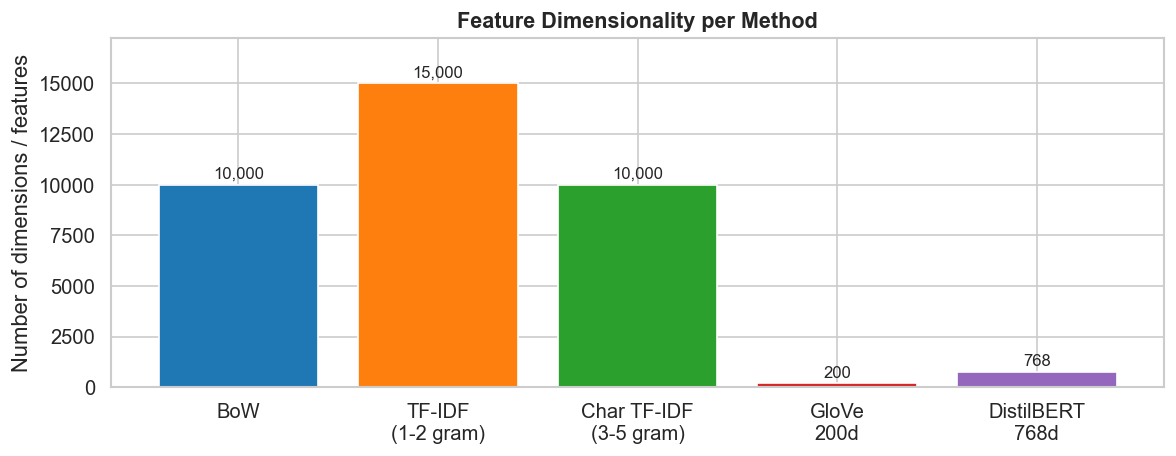

In [28]:
feature_dims = {
    'BoW': 10_000,
    'TF-IDF\n(1-2 gram)': 15_000,
    'Char TF-IDF\n(3-5 gram)': 10_000,
    'GloVe\n200d': 200,
    'DistilBERT\n768d': 768,
}
utils.plot_feature_overview(feature_dims)

---
## 7. Step 1 Summary

### What was accomplished

| Deliverable | Status |
|-------------|--------|
| EDA — class distribution | ✅ |
| EDA — tweet length distribution | ✅ |
| EDA — word frequency analysis | ✅ |
| EDA — word clouds | ✅ |
| Preprocessing pipeline | ✅ |
| Feature: Bag-of-Words | ✅ saved to `features/bow_*.npz` |
| Feature: TF-IDF (word, 1-2 gram) | ✅ saved to `features/tfidf_*.npz` |
| Feature: Char n-gram TF-IDF | ✅ saved to `features/char_tfidf_*.npz` |
| Feature: GloVe Twitter 200d | ✅ saved to `features/glove_*.npy` |
| Feature: DistilBERT 768d | ✅ saved to `features/distilbert_*.npy` |
| Labels saved | ✅ `features/y_train.npy`, `features/y_test.npy` |

### Key findings

- **Severe class imbalance**: 93.0% non-toxic vs 7.0% toxic (13:1 ratio).  
  → In Step 2 (model training) we will use **class weights** and evaluate on **F1-score (macro)** rather than accuracy.
- **Short tweets**: mean 13 words — GloVe averaging and DistilBERT's 128-token limit are both appropriate.
- **5 diverse feature representations** are ready for the classification comparison in the next notebook section.

### Next step — Model Training

Each of the 5 feature sets will be fed into 4 classifiers:
- Naive Bayes (MultinomialNB / GaussianNB depending on feature type)
- Logistic Regression
- SVM (LinearSVC)
- Random Forest

This yields a **5 × 4 comparison matrix** evaluated on Accuracy, Precision, Recall, and F1-score (macro).